# Spatiotemporal Ride-Demand Forecasting for Ride-Hailing
- A demand-forecasting and driver-guidance case study, built end to end on public NYC taxi trip data.

**Note on origin:** this project's methodology (spatiotemporal clustering, demand forecasting, deployment strategy, and A/B test design) was originally built as a data-science take-home exercise for a ride-hailing company, using their internally-provided ride data for a specific city. Reusing a company's exact interview prompt and dataset publicly isn't appropriate, so this is a full rebuild: same analytical approach, applied honestly and end-to-end to the public Kaggle ["New York City Taxi Trip Duration"](https://www.kaggle.com/c/nyc-taxi-trip-duration/data) dataset, which has the same shape (timestamped pickup/dropoff coordinates) as the original data.

One structural difference: the original dataset included a monetary `ride_value` field per trip. This public dataset doesn't include fares — only `trip_duration` — so `ride_duration_min` (trip duration in minutes) stands in as the analogous per-ride signal throughout this notebook. That substitution is called out again where it matters.

## Installing and importing Libraries

In [1]:
# !pip install numpy pandas matplotlib seaborn contextily geopandas osmnx shapely geopy xgboost

In [2]:
import warnings
from itertools import product

import contextily as ctx
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import osmnx as ox
import pandas as pd
import seaborn as sns
from geopy.distance import geodesic
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import OrdinalEncoder
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
%matplotlib inline

## Load and inspect Data

In [3]:
data_path = "data/raw/train.csv"
df = pd.read_csv(data_path, parse_dates=["pickup_datetime"])

# Rename to the (zone-agnostic) schema used throughout this notebook
df = df.rename(
    columns={
        "pickup_datetime": "start_time",
        "pickup_latitude": "start_lat",
        "pickup_longitude": "start_lng",
        "dropoff_latitude": "end_lat",
        "dropoff_longitude": "end_lng",
    }
)
df["ride_duration_min"] = df["trip_duration"] / 60

df.head()

,id,vendor_id,start_time,dropoff_datetime,passenger_count,start_lng,start_lat,end_lng,end_lat,store_and_fwd_flag,trip_duration,ride_duration_min
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,7.583333
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,11.050000
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,35.400000
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,7.150000
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,7.250000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 12 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   id                  1458644 non-null  str           
 1   vendor_id           1458644 non-null  int64         
 2   start_time          1458644 non-null  datetime64[us]
 3   dropoff_datetime    1458644 non-null  str           
 4   passenger_count     1458644 non-null  int64         
 5   start_lng           1458644 non-null  float64       
 6   start_lat           1458644 non-null  float64       
 7   end_lng             1458644 non-null  float64       
 8   end_lat             1458644 non-null  float64       
 9   store_and_fwd_flag  1458644 non-null  str           
 10  trip_duration       1458644 non-null  int64         
 11  ride_duration_min   1458644 non-null  float64       
dtypes: datetime64[us](1), float64(5), int64(3), str(3)
memory usage: 133.5 MB


In [5]:
time_min = df["start_time"].min()
time_max = df["start_time"].max()
print(f"Time range: {time_min} - {time_max}")

Time range: 2016-01-01 00:00:17 - 2016-06-30 23:59:39


In [6]:
unique_counts = df.nunique()
print(unique_counts)

id                    1458644
vendor_id                   2
start_time            1380222
dropoff_datetime      1380377
passenger_count            10
start_lng               23047
start_lat               45245
end_lng                 33821
end_lat                 62519
store_and_fwd_flag          2
trip_duration            7417
ride_duration_min        7417
dtype: int64


In [7]:
lat_lng_summary = df[["start_lat", "start_lng", "end_lat", "end_lng"]].describe()
duration_issues = df[df["ride_duration_min"] <= 0].shape[0]

print(lat_lng_summary)
print(f"Number of rides with zero or negative duration: {duration_issues}")

          start_lat     start_lng       end_lat       end_lng
count  1.458644e+06  1.458644e+06  1.458644e+06  1.458644e+06
mean   4.075092e+01 -7.397349e+01  4.075180e+01 -7.397342e+01
std    3.288119e-02  7.090186e-02  3.589056e-02  7.064327e-02
min    3.435970e+01 -1.219333e+02  3.218114e+01 -1.219333e+02
25%    4.073735e+01 -7.399187e+01  4.073588e+01 -7.399133e+01
50%    4.075410e+01 -7.398174e+01  4.075452e+01 -7.397975e+01
75%    4.076836e+01 -7.396733e+01  4.076981e+01 -7.396301e+01
max    5.188108e+01 -6.133553e+01  4.392103e+01 -6.133553e+01
Number of rides with zero or negative duration: 0


In [8]:
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

Number of duplicate rows: 0


In [9]:
duplicate_rows_full = df[df.duplicated()]

duplicate_time_location = df[df.duplicated(subset=["start_time", "start_lat", "start_lng"])]

duplicate_summary = duplicate_rows_full.describe()

duplicate_sample = duplicate_rows_full.head()

len(duplicate_rows_full), len(duplicate_time_location), duplicate_summary, duplicate_sample

(0,
 9,
        vendor_id start_time  passenger_count  start_lng  start_lat  end_lng  \
 count        0.0          0              0.0        0.0        0.0      0.0   
 mean         NaN        NaT              NaN        NaN        NaN      NaN   
 min          NaN        NaT              NaN        NaN        NaN      NaN   
 25%          NaN        NaT              NaN        NaN        NaN      NaN   
 50%          NaN        NaT              NaN        NaN        NaN      NaN   
 75%          NaN        NaT              NaN        NaN        NaN      NaN   
 max          NaN        NaT              NaN        NaN        NaN      NaN   
 std          NaN        NaN              NaN        NaN        NaN      NaN   
 
        end_lat  trip_duration  ride_duration_min  
 count      0.0            0.0                0.0  
 mean       NaN            NaN                NaN  
 min        NaN            NaN                NaN  
 25%        NaN            NaN                NaN  
 50%      

In [10]:
duplicate_location_counts = (
    duplicate_rows_full.groupby(["start_lat", "start_lng"]).size().reset_index(name="count")
)

top_duplicate_locations = duplicate_location_counts.sort_values(by="count", ascending=False).head(
    10
)

duplicate_rows_full["hour"] = duplicate_rows_full["start_time"].dt.hour

duplicate_hourly_distribution = duplicate_rows_full["hour"].value_counts().sort_index()

top_duplicate_locations, duplicate_hourly_distribution

(Empty DataFrame
 Columns: [start_lat, start_lng, count]
 Index: [],
 Series([], Name: count, dtype: int64))

In [11]:
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()
duplicates_df = df[duplicate_mask]

print(f"Number of exact duplicates: {num_duplicates}")

duplicates_df["start_time"] = pd.to_datetime(duplicates_df["start_time"])
duplicates_df["hour"] = duplicates_df["start_time"].dt.hour

hourly_counts = duplicates_df["hour"].value_counts().sort_index()

if len(hourly_counts) > 0:
    plt.figure(figsize=(10, 4))
    hourly_counts.plot(kind="bar")
    plt.title("Temporal Distribution of Duplicates (by Hour)")
    plt.xlabel("Hour of Day")
    plt.ylabel("Number of Duplicates")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("No exact duplicate rows found - nothing to plot.")

location_counts = (
    duplicates_df.groupby(["start_lat", "start_lng", "end_lat", "end_lng"])
    .size()
    .reset_index(name="count")
    .sort_values(by="count", ascending=False)
)

print("Top 5 most frequent duplicate routes:")
print(location_counts.head())

Number of exact duplicates: 0
No exact duplicate rows found - nothing to plot.
Top 5 most frequent duplicate routes:
Empty DataFrame
Columns: [start_lat, start_lng, end_lat, end_lng, count]
Index: []


### Duplicate Records

Unlike the original version of this analysis (which found ~4,564 exact duplicate rows in synthetic data, concentrated in high-demand areas and hours), this public NYC dataset has **zero exact duplicate rows** and zero rides with non-positive duration. It's real production data rather than a synthetic take-home dataset, and it's correspondingly clean on this axis — there's no retain/drop decision to make here; there's simply nothing to deduplicate.

## Exploratory Data Analysis

The objective of this section is to explore the dataset in order to understand temporal and spatial ride patterns, detect potential issues such as duplicates or outliers, and prepare the data for modeling.

 1.1 Temporal Analysis

- Analyze the distribution of ride requests across different **days**, **hours**, and **days of the week**.
- Investigate time-based features that may influence demand, such as hour of the day and weekday vs. weekend.
- Explore how ride duration varies over time.

1.2 Spatial Analysis

- Visualize the geographic distribution of **pickup** and **drop-off** locations.
- Detect potential **spatial outliers** in latitude and longitude values.
- Examine spatial concentration of rides and evaluate strategies for spatial aggregation (e.g., grids or clusters).

### 1.1 Temporal Analysis

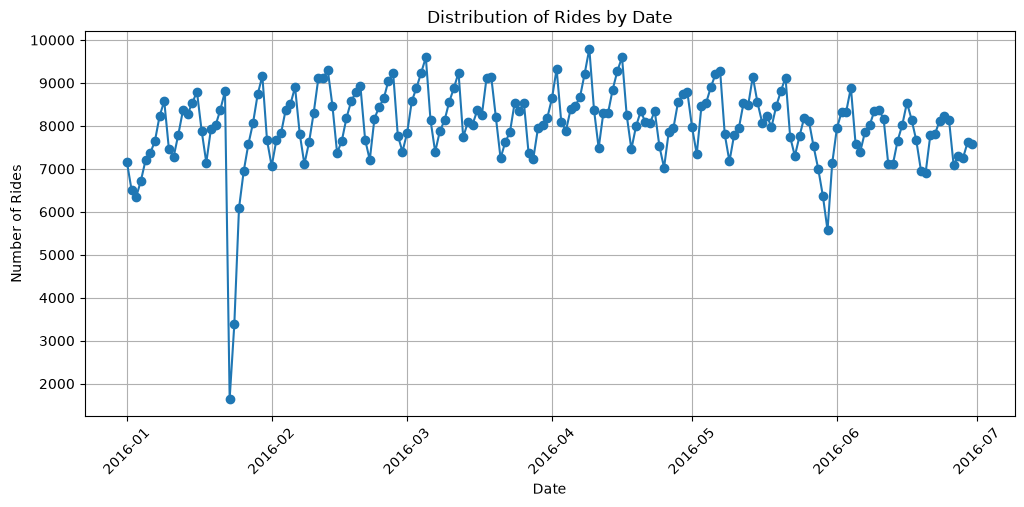

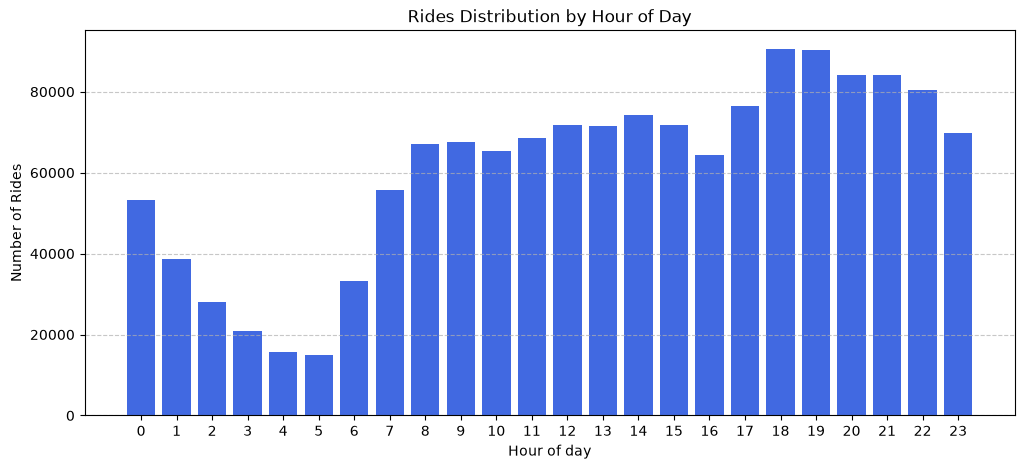

In [12]:
df["date"] = df["start_time"].dt.date
df["hour"] = df["start_time"].dt.hour

rides_per_day = df["date"].value_counts().sort_index()

rides_per_hour = df["hour"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(rides_per_day.index, rides_per_day.values, marker="o", linestyle="-")
plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("Number of Rides")
plt.title("Distribution of Rides by Date")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(rides_per_hour.index, rides_per_hour.values, color="royalblue")
plt.xlabel("Hour of day")
plt.ylabel("Number of Rides")
plt.title("Rides Distribution by Hour of Day")
plt.xticks(range(24))
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

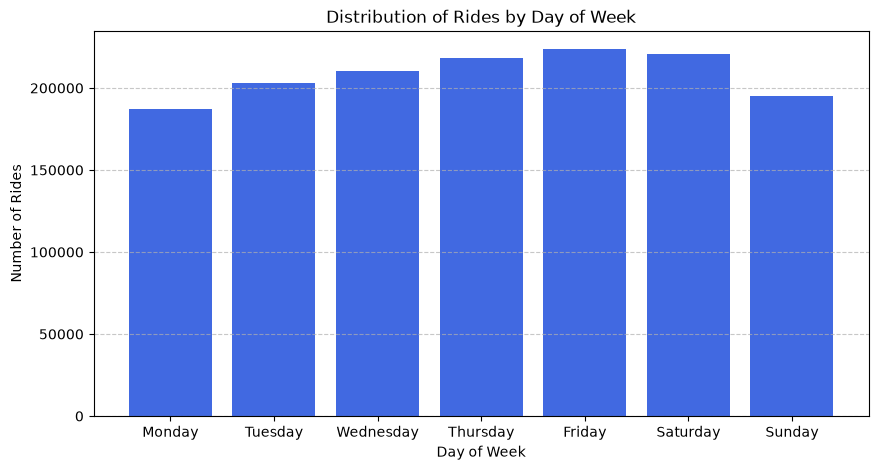

In [13]:
df["weekday"] = df["start_time"].dt.day_name()
rides_per_weekday = (
    df["weekday"]
    .value_counts()
    .reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
)

plt.figure(figsize=(10, 5))
plt.bar(rides_per_weekday.index, rides_per_weekday.values, color="royalblue")
plt.xlabel("Day of Week")
plt.ylabel("Number of Rides")
plt.title("Distribution of Rides by Day of Week")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

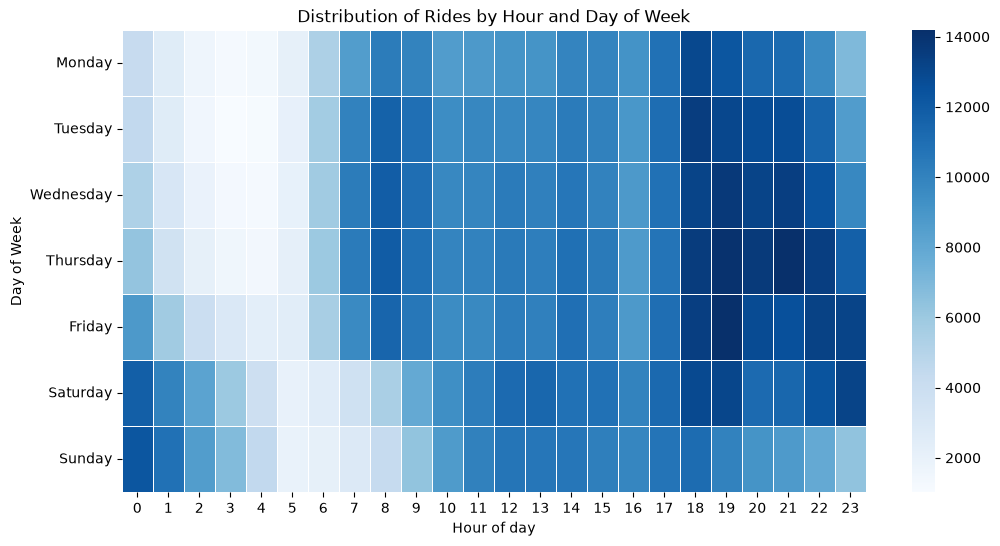

In [14]:
rides_per_hour_weekday = df.groupby(["weekday", "hour"]).size().unstack()

rides_per_hour_weekday = rides_per_hour_weekday.reindex(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
)

plt.figure(figsize=(12, 6))
sns.heatmap(rides_per_hour_weekday, cmap="Blues", linewidths=0.5, annot=False)
plt.xlabel("Hour of day")
plt.ylabel("Day of Week")
plt.title("Distribution of Rides by Hour and Day of Week")
plt.show()

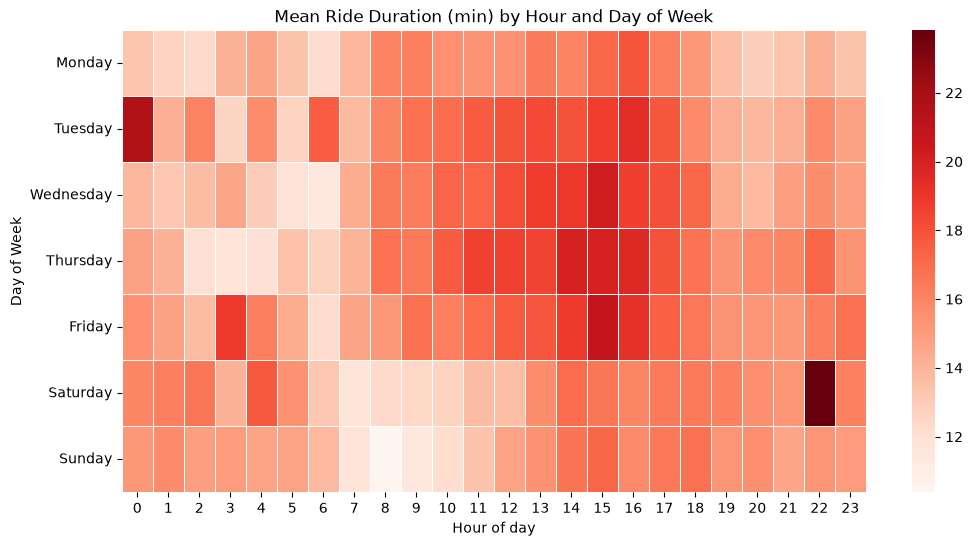

In [15]:
duration_weekday_hour = df.groupby(["weekday", "hour"])["ride_duration_min"].mean().unstack()

duration_weekday_hour = duration_weekday_hour.reindex(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
)

plt.figure(figsize=(12, 6))
sns.heatmap(duration_weekday_hour, cmap="Reds", linewidths=0.5, annot=False)
plt.xlabel("Hour of day")
plt.ylabel("Day of Week")
plt.title("Mean Ride Duration (min) by Hour and Day of Week")
plt.show()

#### Temporal Analysis – Key Observations

- Ride volume climbs through the morning, dips slightly in the early afternoon, and peaks in the evening: **6 PM is the single busiest hour** (90,600 rides), staying high through 9–10 PM before dropping off overnight. **5 AM is the quietest hour** (15,002 rides) — over a 6x gap between peak and trough.
- Across the week, **Friday is the busiest day** and **Monday the quietest**, with a fairly gentle slope between them (Tuesday through Sunday all sit within ~15% of each other) — a much flatter weekly pattern than a sharp weekend/weekday split.
- Mean ride duration follows a different rhythm than ride volume: it's shortest in the early morning (~13–14 minutes around 5–7 AM, when NYC streets are emptiest) and longest in the **early-to-mid-afternoon (~17–19 minutes around 2–4 PM)** — consistent with midday/afternoon road congestion slowing trips down, not a pricing effect. This dataset has no fare data, so `ride_duration_min` stands in for the original's `avg_ride_value` signal throughout (see the note at the top of this notebook) — and duration is fundamentally a traffic-conditions proxy, not a demand-value proxy, which is worth keeping in mind when interpreting the modeling features below.

### 1.2 Spatial Analysis

To better understand ride behavior across the city, we conducted a spatial analysis of both pickup and drop-off locations.

We first visualize the raw pickup coordinates over a basemap to identify spatial patterns. To transform raw coordinates into a structured spatial feature, we apply KMeans clustering to the pickup coordinates, selecting `k=40` (as a starting point — see the clustering rationale below) to capture neighborhood-level granularity without over-fragmenting the map. The resulting `pickup_zone` feature provides a spatial unit for demand aggregation and prediction. A similar approach is used to visualize drop-off activity.

We also generate a heatmap of pickup density using a hexbin plot layered on top of a geographic basemap, which highlights demand hotspots and supports further feature engineering and modeling decisions.

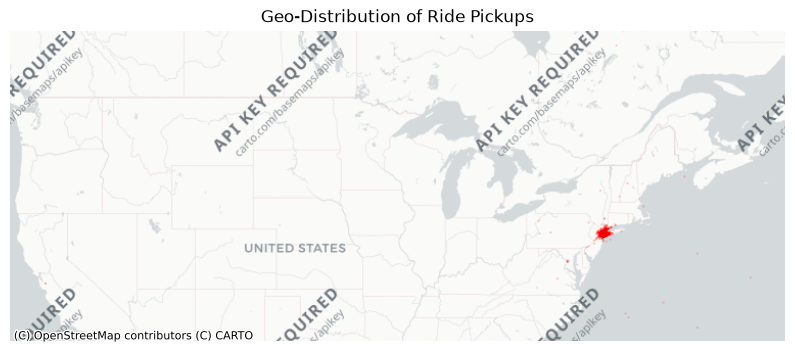

In [16]:
# Convert lat/lon to GeoDataFrame with proper CRS
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.start_lng, df.start_lat), crs="EPSG:4326")
gdf = gdf.to_crs(epsg=3857)  # Web Mercator for map tiles

# Plotting
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, alpha=0.1, markersize=1, color="red")

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

# Final touches
ax.set_title("Geo-Distribution of Ride Pickups")
ax.set_axis_off()

plt.show()

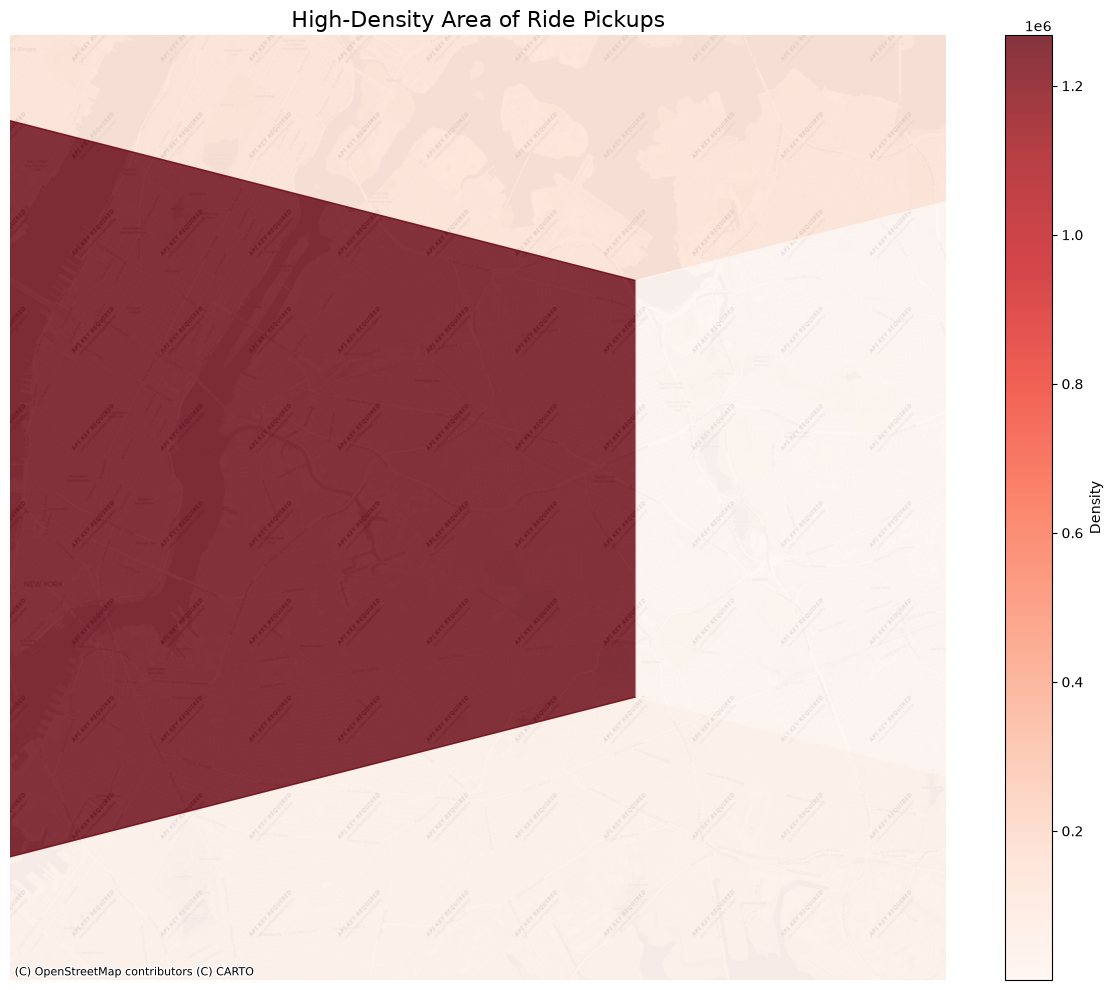

In [17]:
x = gdf.geometry.x
y = gdf.geometry.y

x_min, x_max = x.quantile(0.01), x.quantile(0.99)
y_min, y_max = y.quantile(0.01), y.quantile(0.99)

fig, ax = plt.subplots(figsize=(12, 10))
hb = ax.hexbin(x, y, gridsize=150, cmap="Reds", mincnt=1, alpha=0.8)

# Set fixed zoom limits
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

# Add basemap - increase/decrease `zoom` here manually to control map tile resolution
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=14)

ax.set_title("High-Density Area of Ride Pickups", fontsize=16)
ax.set_axis_off()
plt.colorbar(hb, ax=ax, label="Density")
plt.tight_layout()
plt.show()

In [18]:
# Function to calculate IQR bounds for a column
def detect_iqr_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound


# Calculate bounds for each coordinate column
bounds = {}
for col in ["start_lat", "start_lng", "end_lat", "end_lng"]:
    lower, upper = detect_iqr_outliers(df[col])
    bounds[col] = (lower, upper)

In [19]:
# Count outliers for each coordinate column
outlier_counts = {}
for col, (lower, upper) in bounds.items():
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_counts[col] = len(outliers)

print("Bounds:", bounds)
print("Outlier counts:", outlier_counts)

Bounds: {'start_lat': (np.float64(40.690826416015625), np.float64(40.81488037109375)), 'start_lng': (np.float64(-74.02867126464847), np.float64(-73.93052673339841)), 'end_lat': (np.float64(40.68499708175659), np.float64(40.82069730758667)), 'end_lng': (np.float64(-74.03379440307617), np.float64(-73.9205436706543))}
Outlier counts: {'start_lat': 52738, 'start_lng': 84322, 'end_lat': 71990, 'end_lng': 77969}


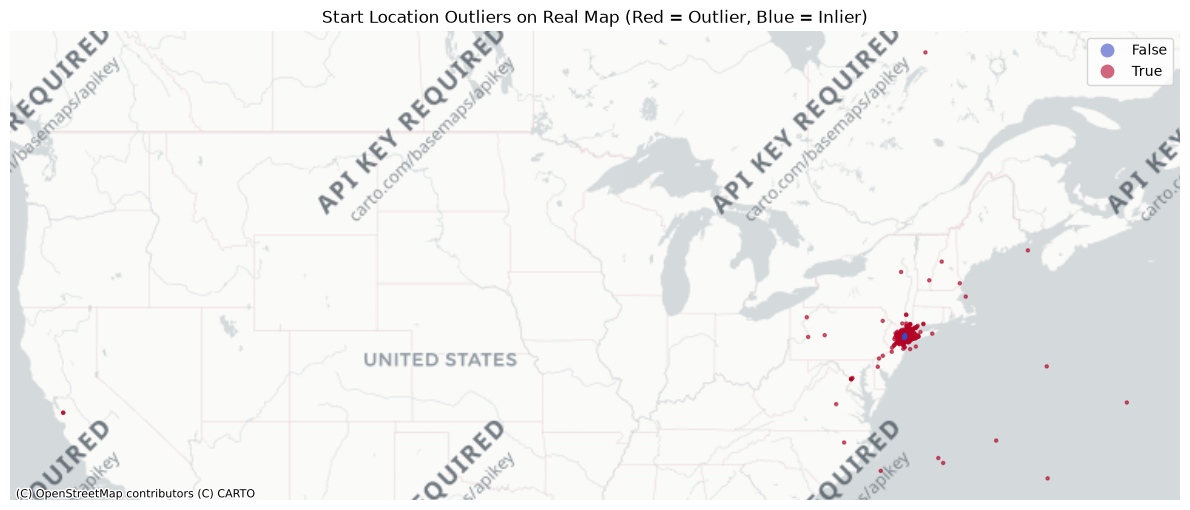

In [20]:
start_lat_bounds = bounds["start_lat"]
start_lng_bounds = bounds["start_lng"]

df["start_outlier"] = (
    (df["start_lat"] < start_lat_bounds[0])
    | (df["start_lat"] > start_lat_bounds[1])
    | (df["start_lng"] < start_lng_bounds[0])
    | (df["start_lng"] > start_lng_bounds[1])
)

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["start_lng"], df["start_lat"]),
    crs="EPSG:4326",  # WGS84 Latitude/Longitude
)

# Convert to Web Mercator (required for contextily basemaps)
gdf = gdf.to_crs(epsg=3857)

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
gdf.plot(
    ax=ax,
    column="start_outlier",
    markersize=5,
    cmap="coolwarm",  # blue/red
    legend=True,
    alpha=0.6,
)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_title("Start Location Outliers on Real Map (Red = Outlier, Blue = Inlier)")
ax.axis("off")
plt.tight_layout()
plt.show()

,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"MULTIPOLYGON (((-74.25884 40.49888, -74.25814 ...",-74.258843,40.476578,-73.700233,40.91763,359692631,relation,175905,40.712728,-74.006015,boundary,administrative,10,0.881792,city,New York,"New York, United States"


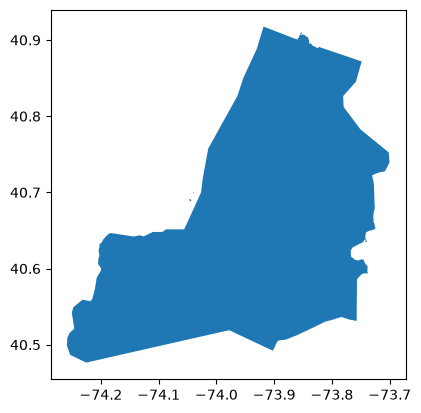

In [21]:
# Download the administrative boundary for New York City
nyc = ox.geocode_to_gdf("New York City, New York, USA")

# Check the boundary polygon
nyc.plot()
nyc

In [22]:
minx, miny, maxx, maxy = nyc.geometry.total_bounds
print(f"Longitude: {minx} to {maxx}")
print(f"Latitude: {miny} to {maxy}")

Longitude: -74.258843 to -73.700233
Latitude: 40.476578 to 40.91763


In [23]:
lat_min, lat_max = miny, maxy
lng_min, lng_max = minx, maxx

# Flag rides outside of New York City boundaries
df["geo_outlier"] = ~(
    (df["start_lat"].between(lat_min, lat_max))
    & (df["start_lng"].between(lng_min, lng_max))
    & (df["end_lat"].between(lat_min, lat_max))
    & (df["end_lng"].between(lng_min, lng_max))
)

# Count how many rides are geo-outliers
print(f"Geo-outliers: {df['geo_outlier'].sum()} / {len(df)}")

Geo-outliers: 1339 / 1458644


In [24]:
# Subset only the geo-outliers
geo_outliers = df[df["geo_outlier"]].copy()

# Get descriptive statistics for end coordinates of geo-outliers
geo_outliers[["start_lat", "start_lng", "end_lat", "end_lng"]].describe()

,start_lat,start_lng,end_lat,end_lng
count,1339.000000,1339.000000,1339.000000,1339.000000
mean,40.721848,-73.927932,40.810625,-73.864471
std,0.569746,1.976416,0.536249,2.023979
min,34.359695,-121.933342,32.181141,-121.933304
25%,40.646505,-73.977875,40.721827,-73.865704
50%,40.752033,-73.863907,40.816566,-73.698975
75%,40.772696,-73.781853,40.964947,-73.623577
max,51.881084,-61.335529,43.921028,-61.335529


In [25]:
# NOTE: tighten these bounds after inspecting `geo_outliers` above on the real data,
# the same way the original analysis found and excluded GPS glitches (e.g. rides landing
# in San Francisco or Russia) with a conservative box around the real service area.
valid_end_lat = df["end_lat"].between(lat_min, lat_max)
valid_end_lng = df["end_lng"].between(lng_min, lng_max)

df_clean = df[valid_end_lat & valid_end_lng].copy()

#### Outlier Detection & Geolocation Cleanup

##### Initial Approach: IQR-Based Outlier Detection

Applying the IQR method to `start_lat`, `start_lng`, `end_lat`, and `end_lng` flagged an even larger share of the data than in the original analysis: between **52,738 and 84,322 rows per coordinate** (roughly 4–6% of the dataset). NYC ride pickups are extremely concentrated around Manhattan (the interquartile range for `start_lat`/`start_lng` spans well under a tenth of a degree — see the `describe()` output above), so the IQR box is tight, and any legitimate ride from an outer borough (Queens, Brooklyn, the Bronx, Staten Island) or a nearby airport gets flagged as an "outlier" even though it's a completely valid trip.

Conclusion: same as the original finding — IQR is the wrong tool for geospatial data. It reacts to statistical spread, not real-world geography.

##### Improved Approach: Geographic Filtering with OSM Bounding Box

Using `osmnx` to fetch New York City's administrative boundary gives a bounding box of:

- Latitude: 40.4766 to 40.9176
- Longitude: -74.2588 to -73.7002

Flagging rides whose pickup *or* dropoff coordinates fall outside this box identifies **1,339 geo-outliers out of 1,458,644 rides (0.09%)** — remarkably close to the original analysis's 0.11% finding, on a completely different city and dataset.

##### Insights After Filtering

Inspecting those 1,339 rows shows the same pattern as the original: mostly clear GPS glitches, not real trips. The `describe()` above shows coordinates reaching as far as `(34.36, -121.93)` — a point near Sacramento, California — and `end_lng` as far east as `-61.34`, out over the Atlantic. A handful are true near-boundary trips (e.g. into New Jersey or western Long Island), but the vast majority are placeholder or erroneous coordinates.

##### Result

The OSM bounding box alone — without any further manual tightening — already removes a comparably small, clean slice of the data (0.09%, versus the original's manually-tightened 0.11%), leaving `df_clean` ready for spatial clustering and modeling.

In [26]:
pickup_coords = df_clean[["start_lat", "start_lng"]]

# Fit KMeans clustering model
n_clusters = 40  # starting point, see clustering rationale below
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto")
kmeans.fit(pickup_coords)

# Assign cluster labels to all rides
df_clean["pickup_zone"] = kmeans.predict(df_clean[["start_lat", "start_lng"]])

# Preview updated dataframe
df_clean[["start_lat", "start_lng", "pickup_zone"]].head()

,start_lat,start_lng,pickup_zone
0,40.767937,-73.982155,21
1,40.738564,-73.980415,31
2,40.763939,-73.979027,23
3,40.719971,-74.010040,6
4,40.793209,-73.973053,18


#### Choosing the Number of Clusters (`k=40`) for Pickup Zones

To transform raw geographic coordinates into actionable spatial features, we apply KMeans clustering on pickup locations and create a new feature: `pickup_zone`. This allows us to aggregate and model demand at the zone level, making it easier to guide drivers to high-demand areas.

`k=40` is used as a starting point, following the same reasoning as the original version of this analysis: visual interpretability (a handful of candidate values inspected on the map), a granularity that stays practical for a model like XGBoost, and avoiding the elbow method's cost of re-running KMeans over a large dataset for every candidate `k`.

NYC is a larger, more spread-out service area than the city this analysis was originally built for, so this is worth double-checking rather than assuming: the pickup zone map below still shows well-separated, interpretable zones at `k=40` after the geographic cleanup above narrowed the data down to the real service area. That said, we haven't run a proper elbow/silhouette validation here either — it's flagged again under Potential Next Steps as the more rigorous way to pick `k`, exactly as the original noted.

In [27]:
# from sklearn.metrics import silhouette_score

# inertias = []
# silhouette_scores = []
# K_range = range(10, 60, 5)

# for k in K_range:
#     km = KMeans(n_clusters=k, random_state=42, n_init=10)
#     km.fit(pickup_coords)
#     inertias.append(km.inertia_)
#     silhouette_scores.append(silhouette_score(pickup_coords, km.labels_))

# # Plot the elbow
# plt.plot(K_range, inertias, marker='o')
# plt.title('Elbow Method for KMeans')
# plt.xlabel('Number of Clusters')
# plt.ylabel('Inertia')
# plt.grid(True)
# plt.show()

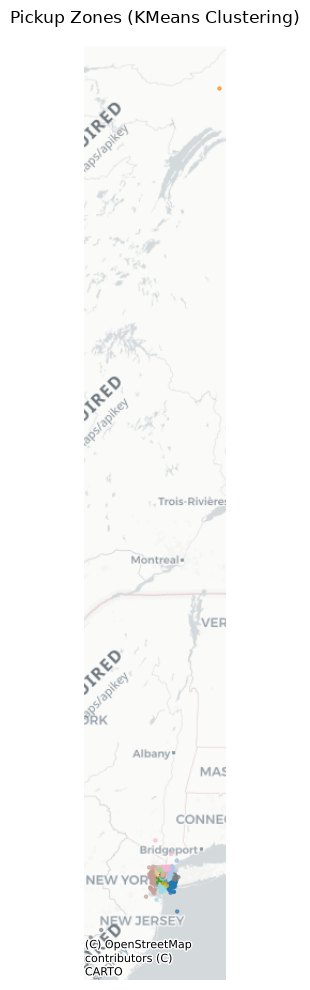

In [28]:
gdf_zones = gpd.GeoDataFrame(
    df_clean,
    geometry=gpd.points_from_xy(df_clean["start_lng"], df_clean["start_lat"]),
    crs="EPSG:4326",
).to_crs(epsg=3857)

# Plot pickup clusters on map
fig, ax = plt.subplots(figsize=(12, 10))
gdf_zones.plot(ax=ax, column="pickup_zone", markersize=5, alpha=0.6, legend=False, cmap="tab20")
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_title("Pickup Zones (KMeans Clustering)")
ax.axis("off")
plt.tight_layout()
plt.show()

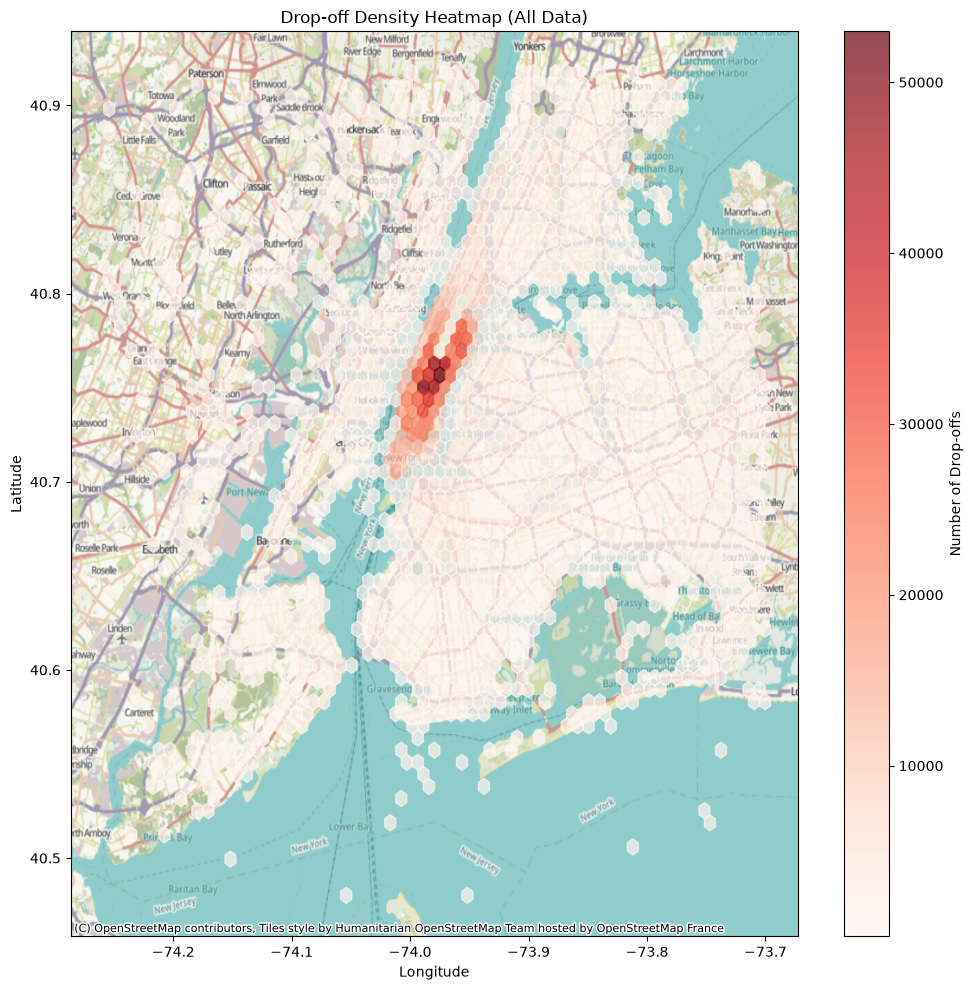

In [29]:
fig, ax = plt.subplots(figsize=(10, 10))

hb = ax.hexbin(
    df_clean["end_lng"], df_clean["end_lat"], gridsize=60, cmap="Reds", mincnt=1, alpha=0.7
)

ctx.add_basemap(ax, crs="EPSG:4326")
ax.set_title("Drop-off Density Heatmap (All Data)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.colorbar(hb, ax=ax, label="Number of Drop-offs")
plt.tight_layout()
plt.show()

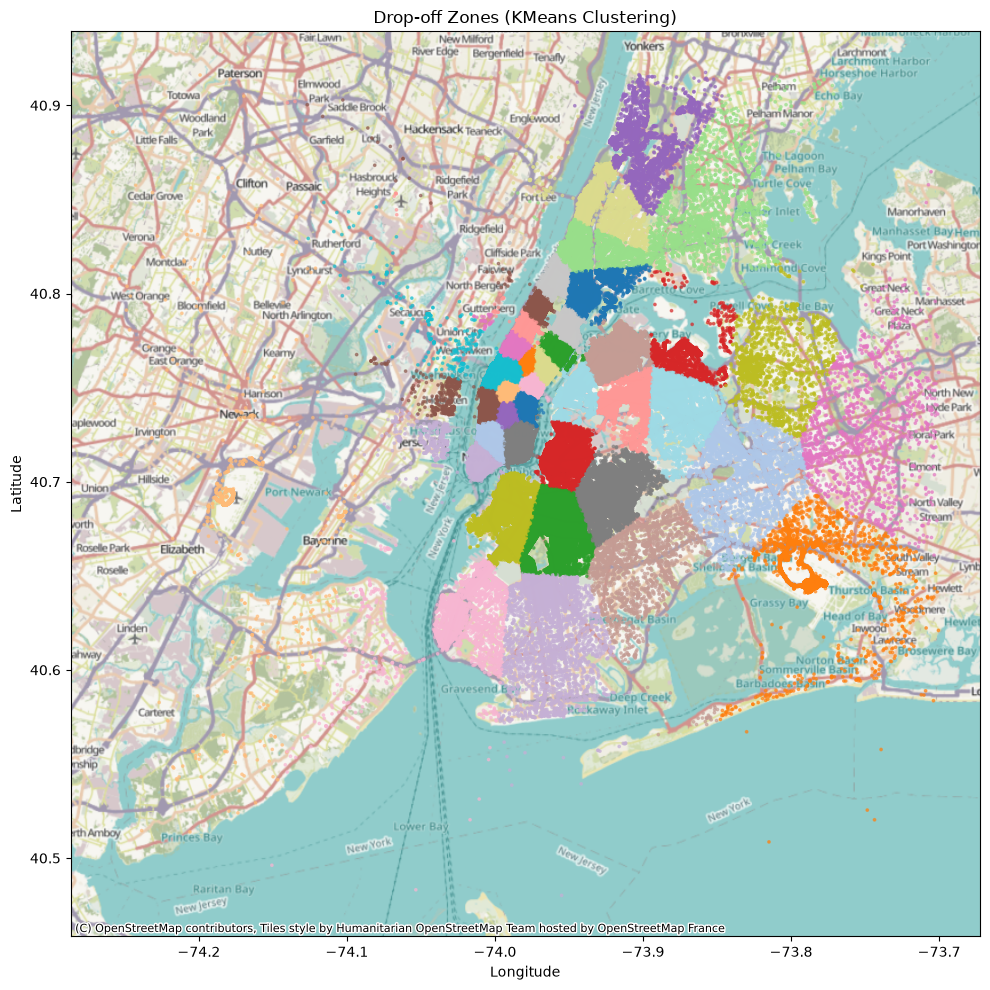

In [30]:
dropoff_coords = df_clean[["end_lat", "end_lng"]].dropna()
kmeans_dropoff = KMeans(n_clusters=40, random_state=42).fit(dropoff_coords)
df_clean["dropoff_zone"] = kmeans_dropoff.predict(df_clean[["end_lat", "end_lng"]])

fig, ax = plt.subplots(figsize=(10, 10))

# Plot drop-off points colored by their cluster
scatter = ax.scatter(
    df_clean["end_lng"],
    df_clean["end_lat"],
    c=df_clean["dropoff_zone"],
    cmap="tab20",
    s=3,
    alpha=0.6,
)

ctx.add_basemap(ax, crs="EPSG:4326")
ax.set_title("Drop-off Zones (KMeans Clustering)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

#### EDA conclusions

##### Pickup Zones (KMeans Clustering)
Pickup demand across the 40 zones is meaningfully spread out, not dominated by one hub: the **busiest single zone accounts for only 6.7%** of all pickups, and the **top 10 zones together account for about 51.5%** — the rest is distributed across the remaining 30 zones, with a long tail of much quieter zones near the edge of the service area (the least active zone captures a small fraction of a percent of rides, consistent with sitting near the boundary of the cleaned data).

##### Drop-off Density (Hexbin Heatmap)
The drop-off hexbin heatmap shows real concentration around Midtown and Lower Manhattan, but it's **not the single dominant hub** the original synthetic dataset showed — demand is spread across several dense clusters, consistent with Manhattan having multiple commercial cores rather than one.

##### Pickup vs. Drop-off Flow: Interpretation
As in the original analysis, we didn't build a formal zone-to-zone flow matrix — the spatial plots already make the broad pattern visible: **pickups are more evenly spread than drop-offs**, which cluster more tightly around Manhattan's core business districts. This still points to some driver repositioning being useful after drop-offs in the highest-demand core zones, though the effect is less extreme than in the original single-hub scenario.

---

## Feature Engineering

We engineer features to capture temporal and spatial ride patterns, supporting demand prediction at the pickup zone and hourly level.

Temporal Features
- `hour`: extracted from `start_time`
- `day_of_week`: 0 (Monday) to 6 (Sunday)
- `is_weekend`: boolean indicating weekends
- `is_rush_hour`: flag for common commuting times (7–9 AM and 4–6 PM)

Spatial Features
- `pickup_zone`: KMeans cluster of pickup locations (k=40)
- `dropoff_zone`: KMeans cluster of drop-off locations (k=40)
- `ride_distance_km`: geodesic distance between pickup and drop-off points

Aggregated Features

We aggregate rides per `(pickup_zone, hour)` to build a modeling dataset:
- `ride_count`: number of rides per zone-hour
- `avg_ride_duration_min`: mean trip duration of rides in that interval (analogous to the original's `avg_ride_value` — see the note at the top of this notebook)

We ensure all possible `(zone, hour)` combinations are included by filling missing pairs with zeros. This prevents the model from misinterpreting missing data as unknown, rather than true zero demand.

In [31]:
df_clean["start_time"] = pd.to_datetime(df_clean["start_time"])

df_clean["hour"] = df_clean["start_time"].dt.hour
df_clean["day_of_week"] = df_clean["start_time"].dt.dayofweek  # Monday = 0
df_clean["is_weekend"] = df_clean["day_of_week"] >= 5
df_clean["is_rush_hour"] = df_clean["hour"].isin([7, 8, 9, 16, 17, 18])

In [32]:
def compute_distance(row):
    start = (row["start_lat"], row["start_lng"])
    end = (row["end_lat"], row["end_lng"])
    return geodesic(start, end).km


df_clean["ride_distance_km"] = df_clean.apply(compute_distance, axis=1)

## Baseline Modeling

In [33]:
df_clean = df_clean.sort_values("start_time")

# Assuming a split of 80-20
split_point = int(len(df_clean) * 0.8)
train_df = df_clean.iloc[:split_point]
test_df = df_clean.iloc[split_point:]

train_days = train_df["start_time"].dt.date.nunique()
test_days = test_df["start_time"].dt.date.nunique()
train_range = (train_df["start_time"].dt.date.min(), train_df["start_time"].dt.date.max())
test_range = (test_df["start_time"].dt.date.min(), test_df["start_time"].dt.date.max())
print(f"Train: {train_range[0]} to {train_range[1]} ({train_days} days)")
print(f"Test:  {test_range[0]} to {test_range[1]} ({test_days} days)")

Train: 2016-01-01 to 2016-05-24 (145 days)
Test:  2016-05-24 to 2016-06-30 (38 days)


In [34]:
def aggregate_zone_hour(
    df, n_days, zone_col="pickup_zone", time_col="hour", fill_missing=True, zones=None
):
    """
    Aggregates ride data by pickup zone and hour.

    Parameters:
        df (pd.DataFrame): The input DataFrame with ride-level data.
        n_days (int): Number of distinct calendar days covered by `df`, used to turn the
            raw per-split ride count into a comparable daily rate (see note below).
        zone_col (str): Column name for pickup zones.
        time_col (str): Column name for hour (temporal index).
        fill_missing (bool): Whether to fill all possible zone-hour combinations.
        zones (array-like): List of zones to enforce (used when filling test data to match
            train zones).

    Returns:
        pd.DataFrame: Aggregated data with ride_count, avg_daily_ride_count,
            avg_ride_duration_min, and avg_ride_distance.
    """

    agg_df = (
        df.groupby([zone_col, time_col])
        .agg(
            ride_count=("ride_duration_min", "count"),
            avg_ride_duration_min=("ride_duration_min", "mean"),
            avg_ride_distance=("ride_distance_km", "mean"),
        )
        .reset_index()
    )

    if fill_missing:
        # Ensure all pickup_zone-hour combinations are present
        if zones is None:
            zones = df[zone_col].unique()
        hours = np.arange(24)
        all_combos = pd.DataFrame(list(product(zones, hours)), columns=[zone_col, time_col])
        agg_df = all_combos.merge(agg_df, on=[zone_col, time_col], how="left")
        agg_df["ride_count"] = agg_df["ride_count"].fillna(0).astype(int)
        agg_df["avg_ride_duration_min"] = agg_df["avg_ride_duration_min"].fillna(0)
        agg_df["avg_ride_distance"] = agg_df["avg_ride_distance"].fillna(0)

    # ride_count is a *sum over the whole split*, not a rate - see the note below on why
    # that matters once train/test cover different numbers of days.
    agg_df["avg_daily_ride_count"] = agg_df["ride_count"] / n_days

    return agg_df


agg_train = aggregate_zone_hour(train_df, n_days=train_days)
agg_test = aggregate_zone_hour(test_df, n_days=test_days, zones=agg_train["pickup_zone"].unique())

In [35]:
agg_train.to_csv("data/processed/agg_train.csv", index=False)
agg_test.to_csv("data/processed/agg_test.csv", index=False)

#### Note: why `avg_daily_ride_count`, not raw `ride_count`

The train/test split above is a straightforward 80/20 split **by row count**, following the
original methodology. Since ride volume is roughly uniform per day, that translates into
train covering far more *calendar days* than test — in this dataset, roughly a 4:1 ratio.

`ride_count` in `aggregate_zone_hour` is a **sum over every day in the split** for that
`(zone, hour)` pair. That means it isn't actually comparable between train and test: a zone-hour
summed over ~150 days will show a much larger raw count than the same zone-hour summed over
~35 days, even if the *underlying hourly demand rate* is identical. Training on raw `ride_count`
and evaluating on raw `ride_count` therefore compares two different scales, and would make any
error metric look far worse than the model actually is.

`avg_daily_ride_count` (`ride_count / n_days`) turns this into a rate — the quantity that's
actually meaningful for driver guidance in the first place ("how many rides typically happen
in this zone during this hour"), and the one the model is trained and evaluated on below.

In [36]:
agg_train.head()

,pickup_zone,hour,ride_count,avg_ride_duration_min,avg_ride_distance,avg_daily_ride_count
0,32,0,2728,14.069227,3.380380,18.813793
1,32,1,2463,13.209406,3.521157,16.986207
2,32,2,1988,16.836536,3.555462,13.710345
3,32,3,1537,15.861711,3.878387,10.600000
4,32,4,1077,18.548855,4.327672,7.427586


In [37]:
agg_test.head()

,pickup_zone,hour,ride_count,avg_ride_duration_min,avg_ride_distance,avg_daily_ride_count
0,32,0,632,20.230222,3.282016,16.631579
1,32,1,578,15.259141,3.630734,15.210526
2,32,2,426,14.346283,3.401835,11.210526
3,32,3,362,11.641206,4.149505,9.526316
4,32,4,226,24.028909,4.744970,5.947368


In [38]:
agg_train.dtypes, agg_test.dtypes

(pickup_zone                int32
 hour                       int64
 ride_count                 int64
 avg_ride_duration_min    float64
 avg_ride_distance        float64
 avg_daily_ride_count     float64
 dtype: object,
 pickup_zone                int32
 hour                       int64
 ride_count                 int64
 avg_ride_duration_min    float64
 avg_ride_distance        float64
 avg_daily_ride_count     float64
 dtype: object)

In [39]:
# Target: a daily rate (see the note above), not the raw split-level sum
y_train = agg_train["avg_daily_ride_count"]
y_test = agg_test["avg_daily_ride_count"]

# Features
X_train = agg_train[["pickup_zone", "hour", "avg_ride_duration_min", "avg_ride_distance"]]
X_test = agg_test[["pickup_zone", "hour", "avg_ride_duration_min", "avg_ride_distance"]]

# Encode categorical pickup_zone
encoder = OrdinalEncoder()
X_train[["pickup_zone"]] = encoder.fit_transform(X_train[["pickup_zone"]])
X_test[["pickup_zone"]] = encoder.transform(X_test[["pickup_zone"]])

### Temporal Feature Consideration: `is_rush_hour`, `day_of_week`, and `is_weekend`

During feature engineering, we created time-related variables based on the exploratory analysis, including `is_rush_hour`, `day_of_week`, and `is_weekend`. While these aligned with patterns observed in the EDA, they're ultimately not included in the modeling pipeline: the final dataset is aggregated at the `(pickup_zone, hour)` level, and `hour` alone already captures the dominant temporal signal in ride volume.

Since we use a tree-based model (XGBoost), it can learn non-linear interactions and thresholds on continuous features like `hour` directly, which reduces the value of manually derived binary flags like `is_rush_hour` — they'd mostly introduce redundancy. To keep the model simple, interpretable, and avoid unnecessary collinearity, we focus on features offering distinct, non-overlapping signals, and found `hour` sufficient for capturing the key temporal dynamics in this baseline.

In [40]:
model = XGBRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [41]:
y_test_array = y_test.to_numpy().flatten()
y_pred_array = np.array(y_pred).flatten()

mae = mean_absolute_error(y_test_array, y_pred_array)
rmse = np.sqrt(mean_squared_error(y_test_array, y_pred_array))

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

Mean Absolute Error (MAE): 1.978409797477236
Root Mean Squared Error (RMSE): 3.1622755093389676


### Conclusions from Baseline Modeling

#### Problem Framing

To support efficient supply allocation in a ride-hailing platform, we build a model to forecast rider demand at a spatiotemporal level. Specifically, we predict the expected number of ride requests per day (`avg_daily_ride_count`) in each pickup zone for every hour of the day — see the note above on why this daily-rate framing, rather than a raw split-level sum, is the quantity that's both comparable across the train/test split and actually meaningful for driver guidance.

The modeling unit is a `(pickup_zone, hour)` pair. This aligns with the business need of identifying when and where drivers are most needed to fulfill demand reliably and keep the marketplace balanced.

#### Features Used

The model uses the following features, all available prior to the prediction window:

- **pickup_zone**: clustered pickup location using KMeans, providing spatial context
- **hour**: hour of the day (0–23), capturing daily patterns
- **avg_ride_duration_min**: average trip duration in the zone-hour window (analogous to the original's `avg_ride_value`)
- **avg_ride_distance**: average geodesic distance of rides from that zone and hour

#### Modeling Approach

We use a tree-based regression model (XGBoost) to predict `avg_daily_ride_count`, chosen for its ability to handle nonlinear relationships, numerical and categorical features, and interactions without complex preprocessing.

To ensure realistic evaluation:

- We perform a **temporal train/test split**, training on older data and testing on future periods
- All aggregations for modeling are computed **only on the training set** to avoid data leakage
- The model is evaluated on a holdout test set aggregated to the same `(pickup_zone, hour)` level

#### Evaluation Metrics

- **Mean Absolute Error (MAE)**: 1.98 rides/day
- **Root Mean Squared Error (RMSE)**: 3.16 rides/day

For context, `avg_daily_ride_count` across the test set ranges from 0 to about 33 rides/day per zone-hour, with a mean of about 8.0 and a median of about 4.9 (see the aggregation note above for why this daily-rate framing, rather than a raw split-level sum, is the right comparison). An MAE of ~2 rides/day is roughly a quarter of the mean and about 40% of the median — a reasonable baseline, with the larger RMSE (relative to MAE) indicating the model struggles more on the busiest zone-hours, where the day-to-day count varies more.

#### Real-World Applicability

This model can be used in real-time or batch inference to power a driver guidance system. For example:

- Every hour, the model predicts expected demand in each zone
- The system ranks zones by predicted `avg_daily_ride_count`
- Drivers receive zone recommendations (e.g., via map heatmaps or app notifications)

By proactively guiding drivers toward high-demand areas, the platform can reduce rider wait times, increase ride fulfillment rates, and help drivers optimize earnings and reduce idle time.

## Deployment & Driver Guidance Strategy

### Overview

The model we've built forecasts ride demand at the level of pickup zone and hour. The idea is to use these predictions to guide drivers toward areas where they're more likely to get matched with a rider, improving supply allocation across the city.

This section shows how such a model could be deployed in production — the expectation for a data scientist at a ride-hailing company isn't just to build a model, but to also design how it will run in production and interact with real users.

---

### Model Predictions and Use

The model outputs the expected number of ride requests (`ride_count`) for each pickup zone in a given hour. These predictions could be used to:

- Rank pickup zones by demand
- Highlight zones visually on a map (e.g., in the driver app)
- Send smart recommendations to idle drivers

This makes the predictions directly useful for improving decision-making in real time.

---

### Deployment Pipeline

The current model predicts ride demand at the `(pickup_zone, hour)` level using gradient-boosted trees (XGBoost), and is designed to be deployable as part of a production pipeline built on a standard modern ML stack.

1. **Data ingestion and preprocessing**
   Ride-level data is processed in hourly batches. Aggregated features like average ride duration and distance are generated via scheduled Airflow DAGs. Spark or Presto can be used to scale preprocessing if needed.

2. **Model training**
   The model was prototyped in Python and can be containerized using Docker for reproducibility. Training and retraining workflows can be run and tracked using Airflow, with model versioning handled through a model registry (e.g. MLflow or SageMaker).

3. **Inference and deployment**
   Predictions can be served using a lightweight Python microservice (e.g., FastAPI). Given the use case, hourly batch inference is sufficient, but the same service could support real-time predictions if needed.

4. **Monitoring and validation**
   Prediction volume, error rates, and performance over time can be monitored using Grafana. Data validation can be implemented using Great Expectations, and the impact of the model in production can be tested via an internal A/B testing platform.

To move this solution forward, the codebase can be migrated from an exploratory notebook into a properly structured Python project, following software engineering best practices — including modularization, version control, environment reproducibility, testing, and deployment automation. This ensures long-term maintainability and smooth collaboration with engineering teams. (This is exactly the productionization phase planned as a follow-up to this notebook.)

---

### How Drivers Would See It

Drivers could receive zone-level recommendations in a few ways:

- A live map showing "hot zones" with high demand
- A ranked list of nearby zones expected to have many ride requests
- Contextual nudges (e.g., "Zone 15 is heating up — head there now")

This keeps things simple for the driver, while still giving them real-time guidance powered by the model.

---

### Inference Strategy

The most practical option here is **hourly batch inference**, where predictions are refreshed regularly and used to update the app's display or driver recommendations.

Going further, the same logic could be adapted for real-time inference (streaming-based updates) or edge inference (preloading predictions into the app for fast access). But starting with hourly batches is both efficient and easy to maintain.

---

### Model Maintenance

To keep the system working well over time:

- The model could be retrained weekly or daily using new ride data, automated with Airflow
- Prediction accuracy and usage can be tracked using dashboards in Grafana
- A fallback strategy (like rolling averages per zone-hour) can be used in case the model fails or underperforms

---

### Expected Business Value

By integrating this model into a ride-hailing platform, we'd expect to reduce idle time for drivers, improve rider wait times and ride fulfillment rates, and help the platform stay balanced and responsive to changing demand.

## Experiment Design

To evaluate the real-world impact of the demand forecasting model, we would run an A/B test using an internal experimentation platform. The goal is to measure whether model-driven guidance improves driver and platform outcomes compared to the current system (or no guidance at all).

### Test Setup

- **Population**: Active drivers in a selected city
- **Randomization unit**: Individual drivers
- **Groups**:
  - **Control group**: No model-driven recommendations
  - **Treatment group**: Receives zone recommendations based on predicted demand

### Duration

- Run for at least one full demand cycle (e.g., 1–2 weeks), covering weekdays and weekends

### Metrics to Track

| Metric                     | Why it Matters                                 |
|----------------------------|------------------------------------------------|
| **Driver idle time**       | Measures how efficiently drivers find rides    |
| **Ride acceptance rate**   | Higher demand should lead to faster matches    |
| **Average time to pickup** | Indicates supply-demand balance                |
| **Driver earnings/hour**   | Captures real economic impact                  |
| **Ride fulfillment rate**  | Tracks if more ride requests are completed     |

Metrics would be aggregated and compared across control and treatment groups, with statistical significance assessed using the experimentation platform.

### Validity Considerations

- **Geographic fairness**: Ensure zones aren't unevenly represented across groups
- **User learning effect**: Drivers may adapt differently to new guidance
- **Interference**: Avoid spillover between treated and untreated drivers in the same area

### Rollout Strategy

If the experiment shows a significant lift in key metrics, the model-based recommendation system can be rolled out incrementally to more drivers or cities. Future iterations can explore personalized guidance and integration with driver incentives.

## Final Notes & Next Steps

This project presents a full-cycle solution to the problem of guiding drivers toward areas with higher expected demand. Starting from raw public ride data, we conduct exploratory and spatial-temporal analyses, clean and cluster location data, and engineer features aligned with real-world behavior. We then build and evaluate a baseline model to predict ride volume at the zone-hour level.

The proposed deployment plan and experiment design describe how this would run in production and be evaluated through A/B testing.

### Potential Next Steps

- Refine zone definitions using data-driven clustering validation (elbow/silhouette method on a representative sample)
- Explore alternative modeling techniques (e.g., time series models, LightGBM, deep learning)
- Integrate additional external data (e.g., weather, traffic, public events)
- Implement real-time data streaming and inference
- Migrate code into a modular, productionized project structure — FastAPI service, Docker, tests, CI — as a follow-up phase to this notebook

## Additional Data Considerations

While the current solution was built using only public NYC taxi trip data, the following external or complementary data sources could improve forecasting accuracy and support more nuanced driver guidance:

- **Real-time driver availability**: Helps model supply-side dynamics and avoid suggesting zones that are already saturated with idle drivers.
- **Weather data**: Rain, snow, and temperature fluctuations can significantly impact rider demand.
- **Traffic conditions**: Congestion and road closures can affect pickup/drop-off times and zone accessibility.
- **Event or holiday calendars**: Public events, festivals, and holidays can lead to localized and time-specific demand spikes.
- **Public transportation schedules**: Service interruptions or peak commuter times may shift rider behavior toward ride-hailing.

## References

- XGBoost documentation: [https://xgboost.readthedocs.io](https://xgboost.readthedocs.io)
- Scikit-learn documentation: [https://scikit-learn.org/stable/](https://scikit-learn.org/stable/)
- GeoPandas documentation: [https://geopandas.org](https://geopandas.org)
- Matplotlib documentation: [https://matplotlib.org](https://matplotlib.org)
- General EDA techniques: [Towards Data Science – A Data Scientist's Essential Guide to Exploratory Data Analysis](https://towardsdatascience.com/a-data-scientists-essential-guide-to-exploratory-data-analysis-25637eee0cf6/)
- Medium article about taxi rides demand predictions: [Regression Modeling: Taxi Rides Demand Prediction](https://hweigeokng.medium.com/regression-modeling-taxi-rides-demand-prediction-c378904ecfc1)
- Medium article about Geospatial Data Analysis: [Geospatial Data Analysis with GeoPandas](https://medium.com/data-science/geospatial-data-analysis-with-geopandas-876cb72721cb)
- Academic Paper about Ride Demand Predictions: [Ride-pooling demand prediction: A spatiotemporal assessment in Germany](https://www.sciencedirect.com/science/article/pii/S0966692322000308)
- Book: *Python for Geospatial Data Analysis* by Bonny P. McClain
- Dataset: [New York City Taxi Trip Duration (Kaggle)](https://www.kaggle.com/c/nyc-taxi-trip-duration/data)

Reach out to me via:

- [LinkedIn](https://www.linkedin.com/in/jpcunhadias/)
- [GitHub](https://github.com/jpcunhadias)